<div style="font-size:30px;font-weight:700;color:#111827;padding-bottom:8px;margin:18px 0;">
CNN CIFAR10 end-to-end 파이프라인
</div>

# CIFAR10 데이터 적재 + 배치 shape·시각화 확인

**목표**: CIFAR10 CIFAR-10 이미지 학습/테스트 데이터를 다운로드해 `DataLoader`로 감싸고, 첫 배치의 shape과 실제 이미지 한 장을 시각으로 확인합니다.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [9]:
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# CIFAR-10 학습/테스트셋 다운로드
training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

print("Train dataset size:", len(training_data))
print("Test dataset size :", len(test_data))

100%|██████████| 170M/170M [24:59<00:00, 114kB/s]


Train dataset size: 50000
Test dataset size : 10000


In [11]:
# CIFAR-10 클래스 이름
cifar10_classes = test_data.classes
print(cifar10_classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [12]:
# 학습/테스트 데이터 로더
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_dataloader))
print("Test batches :", len(test_dataloader))

Train batches: 782
Test batches : 157


In [13]:
# 데이터 형태 확인
for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    print(f"Pixel range: [{X.min():.3f}, {X.max():.3f}]")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64
Pixel range: [0.000, 1.000]


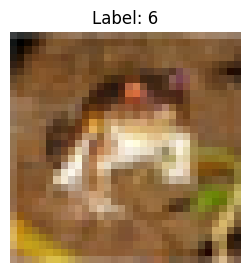

In [14]:
# 한 장 시각화
img, label = training_data[0]
plt.figure(figsize=(3, 3))
plt.imshow(img.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

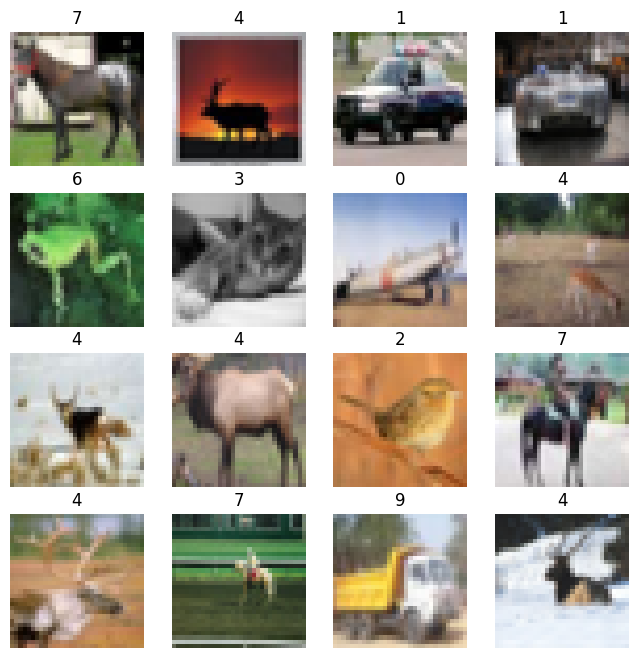

In [15]:
# 여러 장 시각화
figure = plt.figure(figsize=(8, 8))
cols, rows = 4, 4

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]

    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))

plt.show()

# 장치 자동 선택 + Dropout 포함 CNN 모델 정의

**목표**: 가능한 장치(GPU 또는 CPU)를 자동 선택하고, `Conv2d → ReLU → MaxPool2d → Conv2d → ReLU → MaxPool2d → Flatten → Linear → ReLU → Dropout → Linear` 구조의 CNN 모델을 정의합니다.

In [ ]:
pip install torchinfo torchview

In [ ]:
from torchinfo import summary
from torchview import draw_graph

In [ ]:
# 장치 선택 — GPU가 있으면 GPU, 없으면 CPU
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
device

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # 입력: (N, 3, 32, 32)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.3)

        # (N, 3, 32, 32)
        # -> conv1 + pool: (N, 32, 16, 16)
        # -> conv2 + pool: (N, 64, 8, 8)
        # -> conv3 + pool: (N, 128, 4, 4)
        self.flat = nn.Flatten(start_dim=1)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = self.relu(self.conv3(x))
        x = self.pool(x)

        x = self.flat(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        return self.fc2(x)

In [ ]:
model = CNN().to(device)
summary(model, input_size=(1, 3, 32, 32))

In [ ]:
draw_graph(model, input_size=(1, 3, 32, 32)).visual_graph

# 손실·옵티마이저 + 학습/평가 함수 정의

**목표**: `CrossEntropyLoss`와 `Adam` optimizer를 선언하고, 학습 함수 `train()`과 평가 함수 `test()`를 분리해 정의합니다. 각 epoch의 loss와 accuracy를 리스트에 저장해 학습 곡선으로 시각화할 수 있게 합니다.

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()

    train_loss = 0.0
    correct = 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        if batch % 100 == 0:
            current = (batch + 1) * len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")

    train_loss /= num_batches
    train_acc = correct / size

    return train_loss, train_acc

In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.eval()

    test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)

            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    test_acc = correct / size

    print(
        f"Test Error:\n"
        f" Accuracy: {(100 * test_acc):>0.1f}%, "
        f"Avg loss: {test_loss:>8f}\n"
    )

    return test_loss, test_acc

# 5 epoch 학습 실행

**목표**: `train()` + `test()`를 epoch 루프 안에서 호출하여 CIFAR10를 학습합니다. 이 셀은 f-string 줄바꿈 오류가 나지 않도록 `\n`을 사용해 작성되어 있습니다.

In [ ]:
epochs = 10

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for_epoch_message = "Start training"
print(for_epoch_message)

for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")

    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_acc = test(test_dataloader, model, loss_fn)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

print("Done!")

# 학습 곡선 시각화

**목표**: epoch별 train/test loss와 accuracy 변화를 그래프로 확인합니다.

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, epochs + 1), test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o", label="Train Accuracy")
plt.plot(range(1, epochs + 1), test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Test Accuracy: {test_accuracies[-1] * 100:.2f}%")

# Confusion Matrix

**목표**: 테스트셋 전체 예측 결과를 이용해 어떤 이미지 클래스끼리 자주 혼동되는지 확인합니다.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [ ]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X, y in test_dataloader:
        pred = model(X.to(device))

        y_true.extend(y.numpy())
        y_pred.extend(pred.argmax(1).cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

display_labels = test_data.classes

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("CIFAR-10 Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=display_labels
    )
)

# 테스트 이미지 예측 시각화

**목표**: 테스트 이미지 여러 장에 대해 실제 라벨과 모델 예측 라벨을 함께 확인합니다.

In [ ]:
model.eval()

figure = plt.figure(figsize=(10, 10))
cols, rows = 4, 4

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    img, label = test_data[sample_idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        predicted_label = pred.argmax(1).item()

    figure.add_subplot(rows, cols, i)
    plt.title(f"Pred: {predicted_label} / True: {label}")
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))

plt.show()

# 저장 · 재로드 · 단일 추론

**목표**: 학습된 모델 파라미터를 저장하고, 새 `CNN()` 인스턴스에 다시 로드한 뒤 단일 샘플 추론을 수행합니다.

In [ ]:
# 저장
torch.save(model.state_dict(), "cnn_cifar10_model.pth")
print("Saved PyTorch Model State to cnn_cifar10_model.pth")

In [ ]:
# 재로드
loaded_model = CNN().to(device)
loaded_model.load_state_dict(torch.load("cnn_cifar10_model.pth", map_location=device))
loaded_model.eval()

print("Loaded model successfully")

In [ ]:
# 단일 추론
x, y = test_data[0][0], test_data[0][1]

with torch.no_grad():
    pred = loaded_model(x.unsqueeze(0).to(device))
    predicted = pred.argmax(1).item()
    actual = y

print(f'Predicted: "{predicted}", Actual: "{actual}"')

plt.figure(figsize=(3, 3))
plt.imshow(x.permute(1, 2, 0))
plt.title(f"Predicted: {predicted}, Actual: {actual}")
plt.axis("off")
plt.show()